Reprojecting raster data

In [2]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject

In [3]:
raster_file1 = 'germany_population.tif'
raster_file2 = 'germany_elevation.tif'

In [4]:
with rasterio.open(raster_file1) as src1:
    band1 = src1.read(1)
    meta1 = src1.meta

In [5]:
with rasterio.open(raster_file2) as src2:
    band2 = src2.read(1)
    meta2 = src2.meta

In [6]:
meta1

{'driver': 'GTiff',
 'dtype': 'float64',
 'nodata': None,
 'width': 1101,
 'height': 936,
 'count': 1,
 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'),
 'transform': Affine(0.00833333330032682, 0.0, 5.850416665888762,
        0.0, -0.008333333299795073, 55.066249981282525)}

In [7]:
meta2

{'driver': 'GTiff',
 'dtype': 'int16',
 'nodata': None,
 'width': 11004,
 'height': 9354,
 'count': 1,
 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'),
 'transform': Affine(0.0008333333333333333, 0.0, 5.852083333333334,
        0.0, -0.0008333333333333333, 55.065416666666664)}

In [8]:
target_crs = 'EPSG:25832'

In [12]:
def reproject_raster(input_path, output_path, target_crs):
    # Open the input raster file
    with rasterio.open(input_path) as src:
        # Calculate the transform and dimensions for the target CRS
        transform, width, height = calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds)
        
        # Update metadata with new CRS and dimensions
        metadata = src.meta.copy()
        metadata.update({
            'crs': target_crs,
            'transform': transform,
            'width': width,
            'height': height
        })
        
        # Create the output raster file with the new CRS
        with rasterio.open(output_path, 'w', **metadata) as dst:
            # Reproject the data
            for i in range(1, src.count + 1):  # Loop over each band
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=target_crs
                )



In [13]:
# Paths to the input and output files
reprojected_file1 = 'germany_population_reprojected.tif'
reprojected_file2 = 'germany_elevation_reprojected.tif'

# Reproject both raster files
reproject_raster(raster_file1, reprojected_file1, target_crs)
reproject_raster(raster_file2, reprojected_file2, target_crs)

In [14]:
with rasterio.open(reprojected_file1) as src1:
    band1 = src1.read(1)  # Read the data from the first raster
    meta1 = src1.meta  # Metadata for the Europe raster

with rasterio.open(reprojected_file2) as src2:
    band2 = src2.read(1)
    meta2 = src2.meta  # Metadata for the Germany raster

print(meta1['crs'])
print(meta2['crs'])

EPSG:25832
EPSG:25832


In [17]:
from rasterio.warp import Resampling

In [15]:
with rasterio.open(reprojected_file1) as src1:
    res1 = src1.res
    print('resolution: ', res1)

resolution:  (745.7190107123781, 745.7190107123781)


In [16]:
with rasterio.open(reprojected_file2) as src2:
    res2 = src2.res
    print('resolution: ', res2)

resolution:  (74.5694220218926, 74.5694220218926)


In [18]:
with rasterio.open(reprojected_file1) as ref_src:
    target_transform = ref_src.transform
    target_crs = ref_src.crs
    target_width = ref_src.width
    target_height = ref_src.height
    target_resolution = ref_src.res
    target_meta = ref_src.meta.copy()

In [19]:
resampled_file2  = 'germany_elevation_reprojected_resampled.tif'

In [21]:
import numpy as np

In [22]:
with rasterio.open(reprojected_file2) as src:

    aligned_meta = src.meta.copy()
    aligned_meta.update({
        'crs': target_crs,
        'transform': target_transform,
        'width': target_width,
        'height': target_height,
        'dtype': 'float64'
    })


    aligned_data = np.empty((target_height, target_width), dtype=np.float64)

    reproject(
        source = src.read(1),
        destination = aligned_data,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=target_transform,
        dst_crs=target_crs,
        resampling=Resampling.bilinear
        
    )

In [24]:
with rasterio.open(resampled_file2, 'w', **aligned_meta) as dst:
    dst.write(aligned_data, 1)

In [25]:
import os

In [26]:
size_file1 = os.path.getsize(reprojected_file1)
size_file1

8833350

In [28]:
size_file2 = os.path.getsize(resampled_file2)
size_file2

8833350

Create multiband raster data

In [29]:
reprojected_file1 = 'germany_population_reprojected.tif'
aligned_file2 = 'germany_elevation_reprojected_resampled.tif'

In [30]:
output_file = 'combined_raster.tif'

In [32]:
with rasterio.open(reprojected_file1) as src1, rasterio.open(aligned_file2) as src2:
    band1 = src1.read(1)
    band2 = src2.read(1)

    combined_data = np.stack([band1, band2], axis = 0)

    combined_meta = src1.meta.copy()
    combined_meta.update(count = 2)

    with rasterio.open(output_file, 'w', **combined_meta) as dst:
        dst.write(combined_data)

In [34]:
with rasterio.open(output_file) as combined_src:
    band1 = combined_src.read(1)
    band2 = combined_src.read(2)

In [35]:
combined_src.crs

CRS.from_wkt('PROJCS["ETRS89 / UTM zone 32N",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4258"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","25832"]]')

In [36]:
combined_src.res

(745.7190107123781, 745.7190107123781)

<Axes: title={'center': 'Elevation'}>

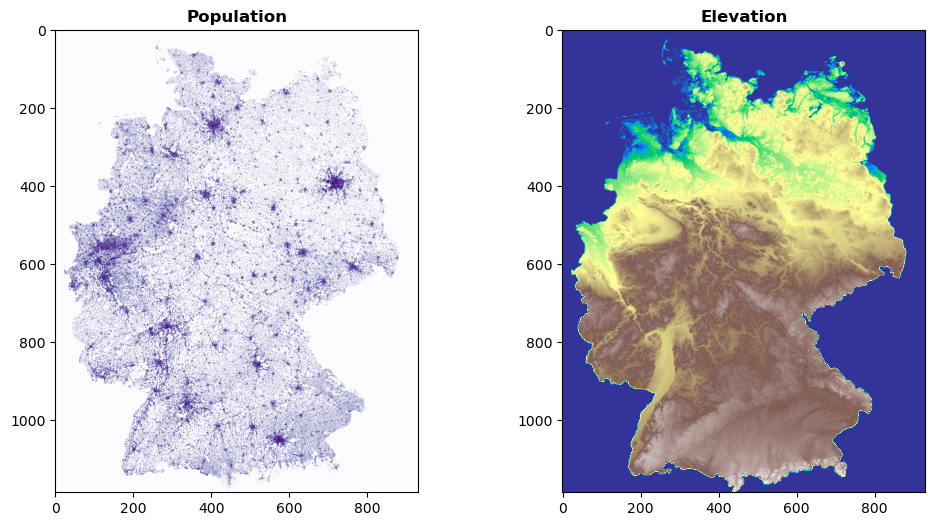

In [41]:
log_band1 = np.log1p(band1)
log_band2 = np.log1p(band2)

import matplotlib.pyplot as plt
from rasterio.plot import show

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12, 6))
show(log_band1, ax = ax1, cmap = 'Purples', title = 'Population')
show(log_band2, ax = ax2, cmap = 'terrain', title = 'Elevation')